# DSC 106 Final Project: CMIP6 Data Preparation

**Project:** Climate Futures Explorer — interactive scrollytelling website

This notebook:
1. Pulls monthly near-surface air temperature (`tas`) and precipitation (`pr`) from the public CMIP6 cloud catalog
2. Computes anomalies relative to a 1995–2014 historical baseline
3. Exports **summary CSVs** for D3 charts (time series + regional aggregates)
4. Exports **gridded JSON fields** for D3 geographic maps (late-century mean anomalies, decimated for web)
5. Downloads a **TopoJSON world basemap** for geographic context
6. Creates 6 static proposal visualizations saved to `../figures/`

**Note**: The first data-loading run takes several minutes because CMIP6 data is large. After the summary tables are cached, re-running export/plotting cells is fast.


## Setup

If a package is missing, uncomment and run the install cell below. The plotting code intentionally avoids Cartopy/GeoPandas so it can run in a lightweight Jupyter/Colab environment.

In [4]:
# Uncomment if needed, especially in a fresh Colab runtime.

%pip install -q intake-esm gcsfs zarr xarray netCDF4 cftime seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import intake
except ImportError as exc:
    raise ImportError("Install intake-esm first: %pip install intake-esm gcsfs zarr") from exc

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 200

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "figures"
DATA_DIR = ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

CATALOG_URL = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
SCENARIOS = ["ssp126", "ssp245", "ssp370", "ssp585"]
SCENARIO_LABELS = {
    "ssp126": "SSP1-2.6 (low emissions)",
    "ssp245": "SSP2-4.5 (middle path)",
    "ssp370": "SSP3-7.0 (high emissions)",
    "ssp585": "SSP5-8.5 (very high emissions)",
}
BASELINE_YEARS = slice("1995", "2014")
MIDCENTURY_YEARS = slice("2041", "2050")
LATECENTURY_YEARS = slice("2091", "2100")

REGIONS = {
    "Arctic": {"lat": (66.5, 90), "lon": (-180, 180)},
    "North America": {"lat": (15, 72), "lon": (-170, -50)},
    "South America": {"lat": (-56, 13), "lon": (-82, -34)},
    "Europe": {"lat": (35, 72), "lon": (-12, 45)},
    "Africa": {"lat": (-35, 37), "lon": (-20, 52)},
    "South Asia": {"lat": (5, 35), "lon": (60, 100)},
    "Australia": {"lat": (-45, -10), "lon": (110, 155)},
}

print("Figures will be saved to", FIG_DIR)
print("Processed tables will be cached in", DATA_DIR)

Figures will be saved to c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures
Processed tables will be cached in c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\data\processed


## Load CMIP6 Data

The code below searches for one model/member combination that has both temperature and precipitation for historical data and the four future scenarios. If the preferred model is not available, it automatically chooses the first complete model it finds.

In [7]:
def choose_complete_model(cat):
    search = cat.search(
        table_id="Amon",
        variable_id=["tas", "pr"],
        experiment_id=["historical", *SCENARIOS],
        member_id="r1i1p1f1",
    )
    df = search.df.copy()
    needed = {(exp, var) for exp in ["historical", *SCENARIOS] for var in ["tas", "pr"]}
    complete = []
    for source_id, group in df.groupby("source_id"):
        found = set(zip(group["experiment_id"], group["variable_id"]))
        if needed.issubset(found):
            complete.append(source_id)
    if not complete:
        raise ValueError("No single CMIP6 model with complete tas/pr coverage was found for the selected scenarios.")

    preferred = ["CanESM5", "MIROC6", "ACCESS-CM2", "MPI-ESM1-2-HR", "GFDL-ESM4"]
    for model in preferred:
        if model in complete:
            return model, df[df["source_id"] == model]
    return complete[0], df[df["source_id"] == complete[0]]


def selected_inventory(cat, model):
    subset = cat.search(
        table_id="Amon",
        variable_id=["tas", "pr"],
        experiment_id=["historical", *SCENARIOS],
        member_id="r1i1p1f1",
        source_id=model,
    )
    rows = subset.df.copy()
    grid_preference = {"gn": 0, "gr": 1, "gr1": 2}
    rows["grid_rank"] = rows["grid_label"].map(grid_preference).fillna(9)
    rows = rows.sort_values(["experiment_id", "variable_id", "grid_rank"])
    return rows.drop_duplicates(["experiment_id", "variable_id"], keep="first")


def open_cmip6_datasets(inventory):
    dsets = {}
    for _, row in inventory.iterrows():
        key = (row["experiment_id"], row["variable_id"])
        print(f"Opening {key[0]} {key[1]} from {row['zstore']}")
        ds = xr.open_zarr(row["zstore"], consolidated=True, storage_options={"token": "anon"})
        ds.attrs["experiment_id"] = row["experiment_id"]
        ds.attrs["variable_id"] = row["variable_id"]
        dsets[key] = ds
    return dsets


cat = intake.open_esm_datastore(CATALOG_URL)
MODEL, model_rows = choose_complete_model(cat)
print(f"Using CMIP6 model: {MODEL}")
inventory = selected_inventory(cat, MODEL)
display(inventory[["source_id", "experiment_id", "variable_id", "member_id", "grid_label", "zstore"]].sort_values(["experiment_id", "variable_id"]))

Using CMIP6 model: CanESM5


,source_id,experiment_id,variable_id,member_id,grid_label,zstore
5,CanESM5,historical,pr,r1i1p1f1,gn,gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical...
4,CanESM5,historical,tas,r1i1p1f1,gn,gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical...
9,CanESM5,ssp126,pr,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
8,CanESM5,ssp126,tas,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
6,CanESM5,ssp245,pr,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
7,CanESM5,ssp245,tas,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
0,CanESM5,ssp370,pr,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
1,CanESM5,ssp370,tas,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
3,CanESM5,ssp585,pr,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...
2,CanESM5,ssp585,tas,r1i1p1f1,gn,gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp...


In [8]:
dsets = open_cmip6_datasets(inventory)
list(dsets.keys())[:5], len(dsets)

Opening historical pr from gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/Amon/pr/gn/v20190429/
Opening historical tas from gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r1i1p1f1/Amon/tas/gn/v20190429/
Opening ssp126 pr from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp126/r1i1p1f1/Amon/pr/gn/v20190429/


C:\Users\Jonat\AppData\Local\Temp\ipykernel_33048\1664431367.py:45: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(row["zstore"], consolidated=True, storage_options={"token": "anon"})


Opening ssp126 tas from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp126/r1i1p1f1/Amon/tas/gn/v20190429/


C:\Users\Jonat\AppData\Local\Temp\ipykernel_33048\1664431367.py:45: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(row["zstore"], consolidated=True, storage_options={"token": "anon"})


Opening ssp245 pr from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp245/r1i1p1f1/Amon/pr/gn/v20190429/
Opening ssp245 tas from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp245/r1i1p1f1/Amon/tas/gn/v20190429/
Opening ssp370 pr from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/Amon/pr/gn/v20190429/
Opening ssp370 tas from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp370/r1i1p1f1/Amon/tas/gn/v20190429/
Opening ssp585 pr from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp585/r1i1p1f1/Amon/pr/gn/v20190429/


C:\Users\Jonat\AppData\Local\Temp\ipykernel_33048\1664431367.py:45: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(row["zstore"], consolidated=True, storage_options={"token": "anon"})


Opening ssp585 tas from gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp585/r1i1p1f1/Amon/tas/gn/v20190429/


C:\Users\Jonat\AppData\Local\Temp\ipykernel_33048\1664431367.py:45: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(row["zstore"], consolidated=True, storage_options={"token": "anon"})


([('historical', 'pr'),
  ('historical', 'tas'),
  ('ssp126', 'pr'),
  ('ssp126', 'tas'),
  ('ssp245', 'pr')],
 10)

## Process Data

Transformations:

- Temperature is converted from Kelvin to Celsius.
- Precipitation is converted from kg m^-2 s^-1 to mm/day.
- Future values are expressed as anomalies relative to the 1995-2014 historical baseline.
- Regional averages use cosine latitude weights so large high-latitude grid cells do not dominate the mean.

In [9]:
def pick_dataset(dsets, experiment_id, variable_id):
    try:
        return dsets[(experiment_id, variable_id)]
    except KeyError as exc:
        raise KeyError(f"Could not find {variable_id} for {experiment_id}") from exc


def standardize_lon(da):
    if "lon" not in da.coords:
        return da
    lon = (((da["lon"] + 180) % 360) - 180)
    da = da.assign_coords(lon=lon).sortby("lon")
    return da


def annualize(da, variable_id):
    da = standardize_lon(da)
    if variable_id == "tas":
        da = da - 273.15
        da.attrs["units"] = "degC"
    elif variable_id == "pr":
        da = da * 86400
        da.attrs["units"] = "mm/day"
    return da.groupby("time.year").mean("time", skipna=True)


def area_weighted_mean(da):
    weights = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(weights).mean(("lat", "lon"), skipna=True)


def subset_region(da, bounds):
    lat0, lat1 = bounds["lat"]
    lon0, lon1 = bounds["lon"]
    return da.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1))


def period_mean(da, year_slice):
    start = int(year_slice.start)
    stop = int(year_slice.stop)
    return da.sel(year=slice(start, stop)).mean("year", skipna=True)


historical = {}
future = {scenario: {} for scenario in SCENARIOS}

for variable in ["tas", "pr"]:
    historical[variable] = annualize(pick_dataset(dsets, "historical", variable)[variable], variable)
    for scenario in SCENARIOS:
        future[scenario][variable] = annualize(pick_dataset(dsets, scenario, variable)[variable], variable)

baseline = {variable: period_mean(historical[variable], BASELINE_YEARS) for variable in ["tas", "pr"]}
print("Loaded annual fields for temperature and precipitation.")

Loaded annual fields for temperature and precipitation.


In [20]:
summary_rows = []
timeseries_rows = []

for scenario in SCENARIOS:
    for variable in ["tas", "pr"]:
        anomaly = future[scenario][variable] - baseline[variable]

        global_series = area_weighted_mean(anomaly).compute()
        for year, value in zip(global_series["year"].values, global_series.values):
            timeseries_rows.append({
                "scenario": scenario,
                "scenario_label": SCENARIO_LABELS[scenario],
                "variable": variable,
                "region": "Global",
                "year": int(year),
                "anomaly": float(value),
            })

        for region_name, bounds in REGIONS.items():
            regional = area_weighted_mean(subset_region(anomaly, bounds)).compute()
            for year, value in zip(regional["year"].values, regional.values):
                timeseries_rows.append({
                    "scenario": scenario,
                    "scenario_label": SCENARIO_LABELS[scenario],
                    "variable": variable,
                    "region": region_name,
                    "year": int(year),
                    "anomaly": float(value),
                })

            mid = regional.sel(year=slice(2041, 2050)).mean().item()
            late = regional.sel(year=slice(2091, 2100)).mean().item()
            summary_rows.append({
                "scenario": scenario,
                "scenario_label": SCENARIO_LABELS[scenario],
                "variable": variable,
                "region": region_name,
                "midcentury_anomaly": float(mid),
                "latecentury_anomaly": float(late),
            })

summary = pd.DataFrame(summary_rows)
timeseries = pd.DataFrame(timeseries_rows)
summary.to_csv(DATA_DIR / "cmip6_region_summary.csv", index=False)
timeseries.to_csv(DATA_DIR / "cmip6_anomaly_timeseries.csv", index=False)

display(summary.head())
display(timeseries.head())

,scenario,scenario_label,variable,region,midcentury_anomaly,latecentury_anomaly
0,ssp126,SSP1-2.6 (low emissions),tas,Arctic,5.551628,6.337438
1,ssp126,SSP1-2.6 (low emissions),tas,North America,1.952155,2.134472
2,ssp126,SSP1-2.6 (low emissions),tas,South America,1.103616,1.235188
3,ssp126,SSP1-2.6 (low emissions),tas,Europe,1.871336,2.269303
4,ssp126,SSP1-2.6 (low emissions),tas,Africa,1.287261,1.319786


,scenario,scenario_label,variable,region,year,anomaly
0,ssp126,SSP1-2.6 (low emissions),tas,Global,2015,0.316014
1,ssp126,SSP1-2.6 (low emissions),tas,Global,2016,0.344402
2,ssp126,SSP1-2.6 (low emissions),tas,Global,2017,0.563932
3,ssp126,SSP1-2.6 (low emissions),tas,Global,2018,0.474171
4,ssp126,SSP1-2.6 (low emissions),tas,Global,2019,0.406289


## Export Gridded Data for Interactive D3

The cells below export:
1. **World basemap** — TopoJSON from the Natural Earth dataset (via the `topojson` world-atlas)
2. **Gridded anomaly fields** — Late-century (2091–2100) mean temperature and precipitation anomalies for each SSP scenario, saved as JSON arrays for D3 to render as geo-positioned rectangles.

Each grid file contains a list of `{lat, lon, value}` objects, where `value` is the anomaly relative to the 1995–2014 baseline. Grid lines have been decimated to every 2nd cell to keep file sizes manageable for browser loading.


In [21]:
import json
import urllib.request

WORLD_TOPO_URL = "https://cdn.jsdelivr.net/npm/world-atlas@2/countries-110m.json"
WORLD_TOPO_PATH = DATA_DIR / "world-110m.json"

if not WORLD_TOPO_PATH.exists():
    print(f"Downloading world basemap from {WORLD_TOPO_URL} ...")
    urllib.request.urlretrieve(WORLD_TOPO_URL, WORLD_TOPO_PATH)
    print(f"Saved to {WORLD_TOPO_PATH}")
else:
    print(f"World basemap already exists at {WORLD_TOPO_PATH}")

# Verify it's valid JSON
with open(WORLD_TOPO_PATH) as f:
    topo = json.load(f)
print(f"  → {len(topo['objects']['countries']['geometries'])} countries loaded")


World basemap already exists at c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\data\processed\world-110m.json
  → 177 countries loaded


In [22]:
GRID_DIR = DATA_DIR / "grids"
GRID_DIR.mkdir(parents=True, exist_ok=True)

# Decimate factor: take every Nth grid cell to keep file sizes manageable
# Factor of 2 → ~25% of original grid cells
DECIMATE = 2

VARIABLE_LABELS = {
    "tas": "tas",
    "pr": "pr",
}

exported = []
for scenario in SCENARIOS:
    for variable in ["tas", "pr"]:
        # Compute late-century mean anomaly field
        anomaly_field = period_mean(future[scenario][variable] - baseline[variable], LATECENTURY_YEARS)
        field_computed = anomaly_field.compute()

        lat_vals = field_computed["lat"].values[::DECIMATE]
        lon_vals = field_computed["lon"].values[::DECIMATE]
        grid_values = field_computed.values[::DECIMATE, ::DECIMATE]

        records = []
        for i, lat in enumerate(lat_vals):
            for j, lon in enumerate(lon_vals):
                val = grid_values[i, j]
                if not np.isnan(val):
                    records.append({
                        "lat": round(float(lat), 2),
                        "lon": round(float(lon), 2),
                        "value": round(float(val), 3),
                    })

        filename = f"{scenario}_{variable}_latecentury.json"
        filepath = GRID_DIR / filename
        with open(filepath, "w") as f:
            json.dump(records, f, separators=(",", ":"))

        file_size = filepath.stat().st_size
        exported.append(f"  {filename}: {len(records):,} cells, {file_size / 1024:.1f} KB")

print("Exported gridded anomaly fields:")
for line in exported:
    print(line)


Exported gridded anomaly fields:
  ssp126_tas_latecentury.json: 2,048 cells, 81.6 KB
  ssp126_pr_latecentury.json: 2,048 cells, 82.0 KB
  ssp245_tas_latecentury.json: 2,048 cells, 81.7 KB
  ssp245_pr_latecentury.json: 2,048 cells, 82.0 KB
  ssp370_tas_latecentury.json: 2,048 cells, 81.8 KB
  ssp370_pr_latecentury.json: 2,048 cells, 82.1 KB
  ssp585_tas_latecentury.json: 2,048 cells, 81.9 KB
  ssp585_pr_latecentury.json: 2,048 cells, 82.1 KB


## Plot Helpers

In [13]:
def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved {path}")


def plot_global_map(field, title, cbar_label, cmap, vmin=None, vmax=None, filename="map.png"):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    mesh = ax.pcolormesh(field["lon"], field["lat"], field, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title, loc="left", fontsize=14, weight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.grid(color="white", linewidth=0.35, alpha=0.6)
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(cbar_label)
    savefig(filename)
    plt.show()

## Visualization 1: Global Temperature Change Map for 2100

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\01_global_temperature_change_map.png


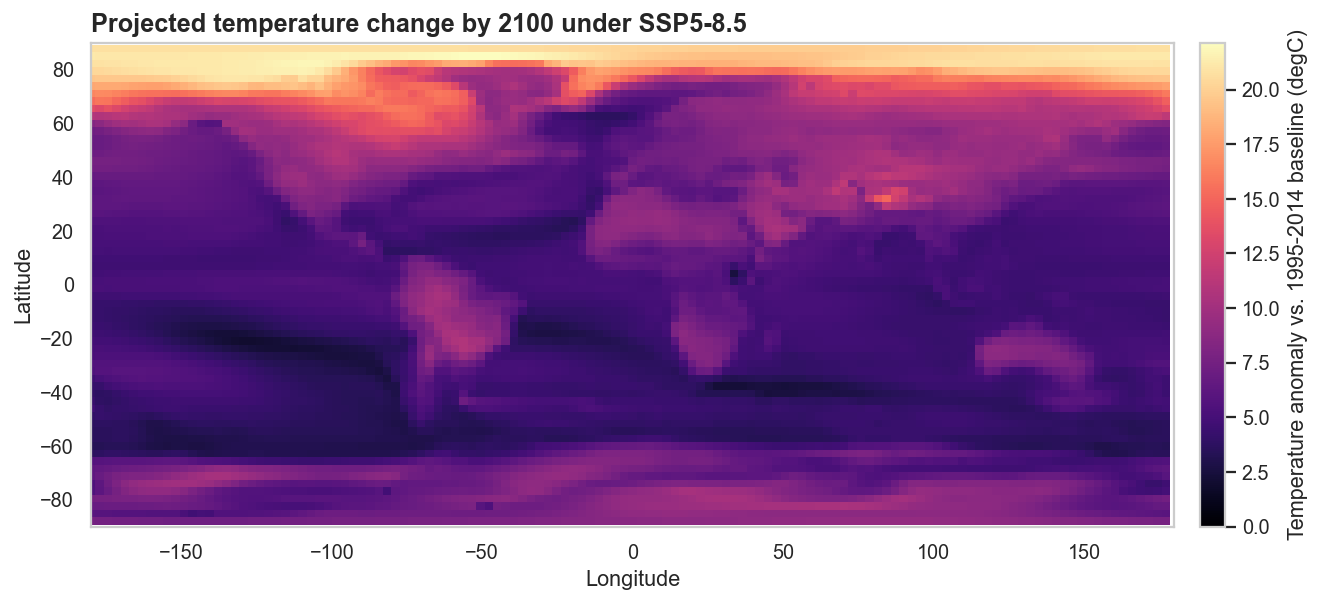

In [23]:
temp_2100 = period_mean(future["ssp585"]["tas"] - baseline["tas"], LATECENTURY_YEARS).compute()
plot_global_map(
    temp_2100,
    "Projected temperature change by 2100 under SSP5-8.5",
    "Temperature anomaly vs. 1995-2014 baseline (degC)",
    cmap="magma",
    vmin=0,
    filename="01_global_temperature_change_map.png",
)

## Visualization 2: Global Precipitation Change Map for 2100

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\02_global_precipitation_change_map.png


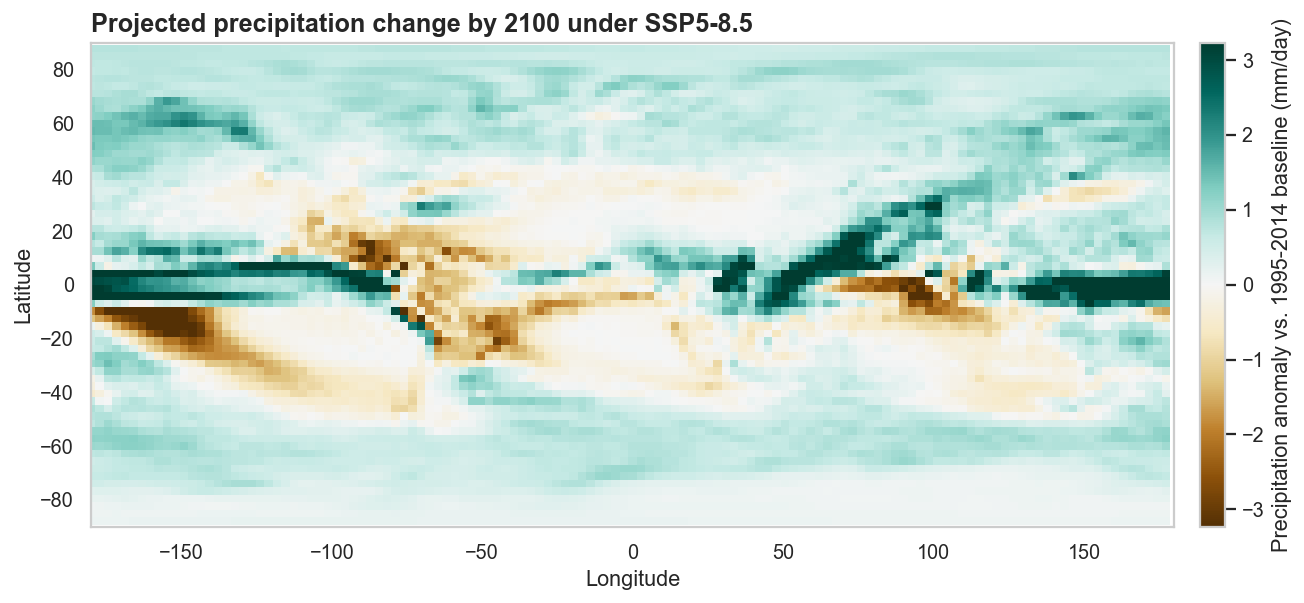

In [24]:
precip_2100 = period_mean(future["ssp585"]["pr"] - baseline["pr"], LATECENTURY_YEARS).compute()
limit = float(np.nanpercentile(np.abs(precip_2100.values), 98))
plot_global_map(
    precip_2100,
    "Projected precipitation change by 2100 under SSP5-8.5",
    "Precipitation anomaly vs. 1995-2014 baseline (mm/day)",
    cmap="BrBG",
    vmin=-limit,
    vmax=limit,
    filename="02_global_precipitation_change_map.png",
)

## Visualization 3: Scenario Comparison Line Chart

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\03_scenario_temperature_lines.png


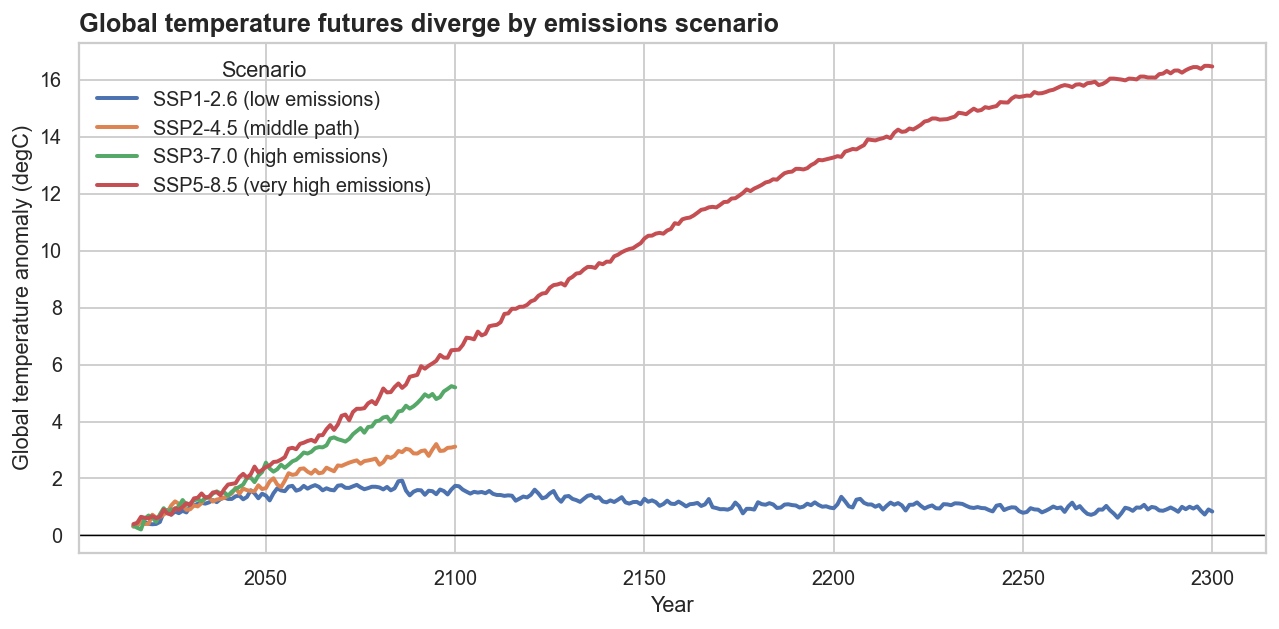

In [25]:
plot_df = timeseries[(timeseries["variable"] == "tas") & (timeseries["region"] == "Global")].copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=plot_df, x="year", y="anomaly", hue="scenario_label", linewidth=2.2, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Global temperature futures diverge by emissions scenario", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Global temperature anomaly (degC)")
ax.legend(title="Scenario", frameon=False, loc="upper left")
savefig("03_scenario_temperature_lines.png")
plt.show()

## Visualization 4: Regional Warming Comparison Bar Chart

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\04_regional_warming_bars.png


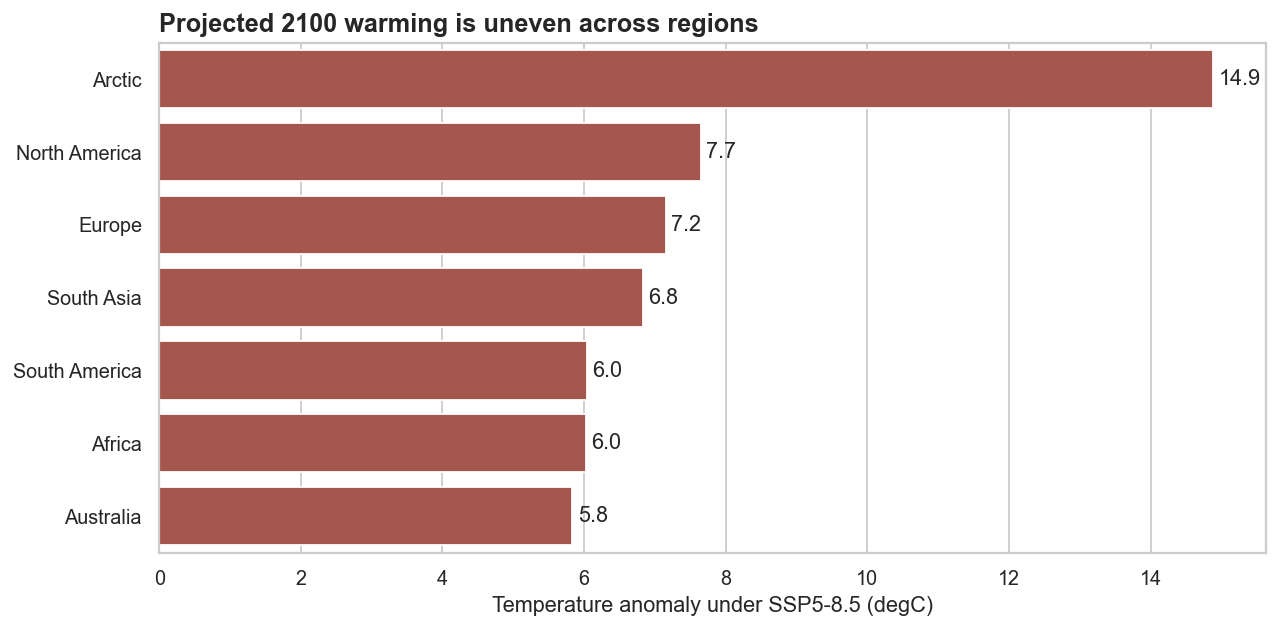

In [26]:
bar_df = summary[(summary["variable"] == "tas") & (summary["scenario"] == "ssp585")].copy()
bar_df = bar_df.sort_values("latecentury_anomaly", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=bar_df, x="latecentury_anomaly", y="region", color="#b44b3f", ax=ax)
ax.set_title("Projected 2100 warming is uneven across regions", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Temperature anomaly under SSP5-8.5 (degC)")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
savefig("04_regional_warming_bars.png")
plt.show()

## Visualization 5: Temperature vs. Precipitation Change Scatterplot

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\05_temperature_precipitation_scatter.png


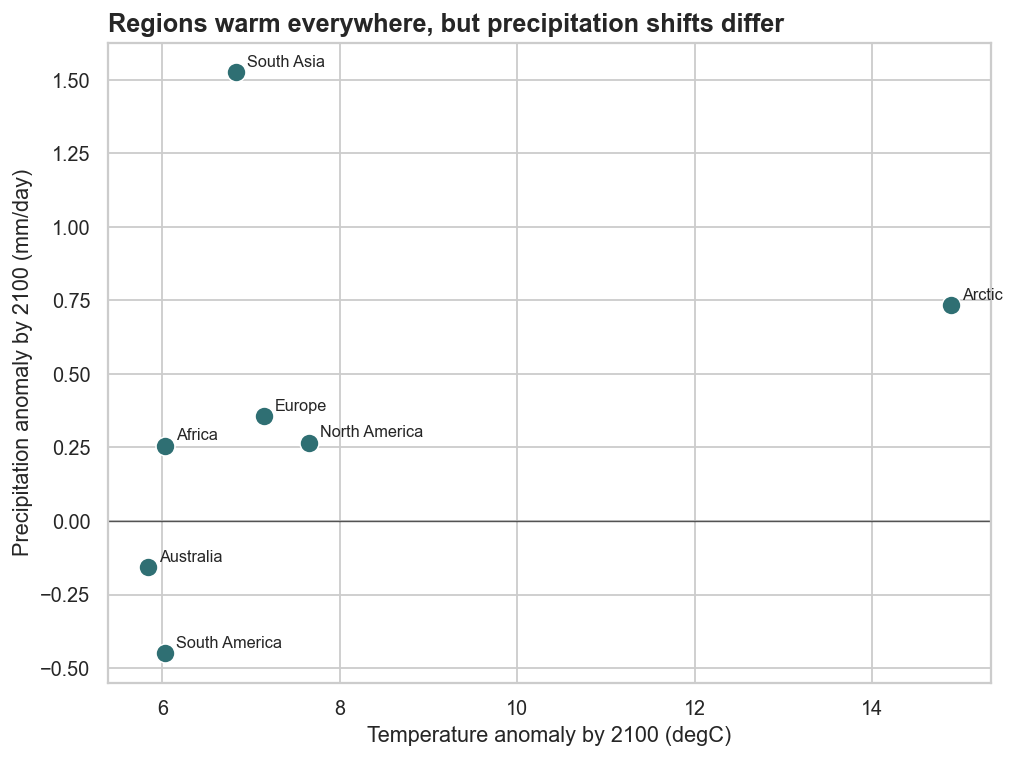

In [27]:
scatter_df = summary[summary["scenario"] == "ssp585"].pivot_table(
    index="region",
    columns="variable",
    values="latecentury_anomaly",
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=scatter_df, x="tas", y="pr", s=110, color="#2f6f73", ax=ax)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_title("Regions warm everywhere, but precipitation shifts differ", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Temperature anomaly by 2100 (degC)")
ax.set_ylabel("Precipitation anomaly by 2100 (mm/day)")
for _, row in scatter_df.iterrows():
    ax.annotate(row["region"], (row["tas"], row["pr"]), xytext=(6, 3), textcoords="offset points", fontsize=9)
savefig("05_temperature_precipitation_scatter.png")
plt.show()

## Visualization 6: Regional Heatmap Over Time

Saved c:\Users\Jonat\UCSD\2025-2026\DSC 106\team_vizionary\figures\06_regional_temperature_heatmap.png


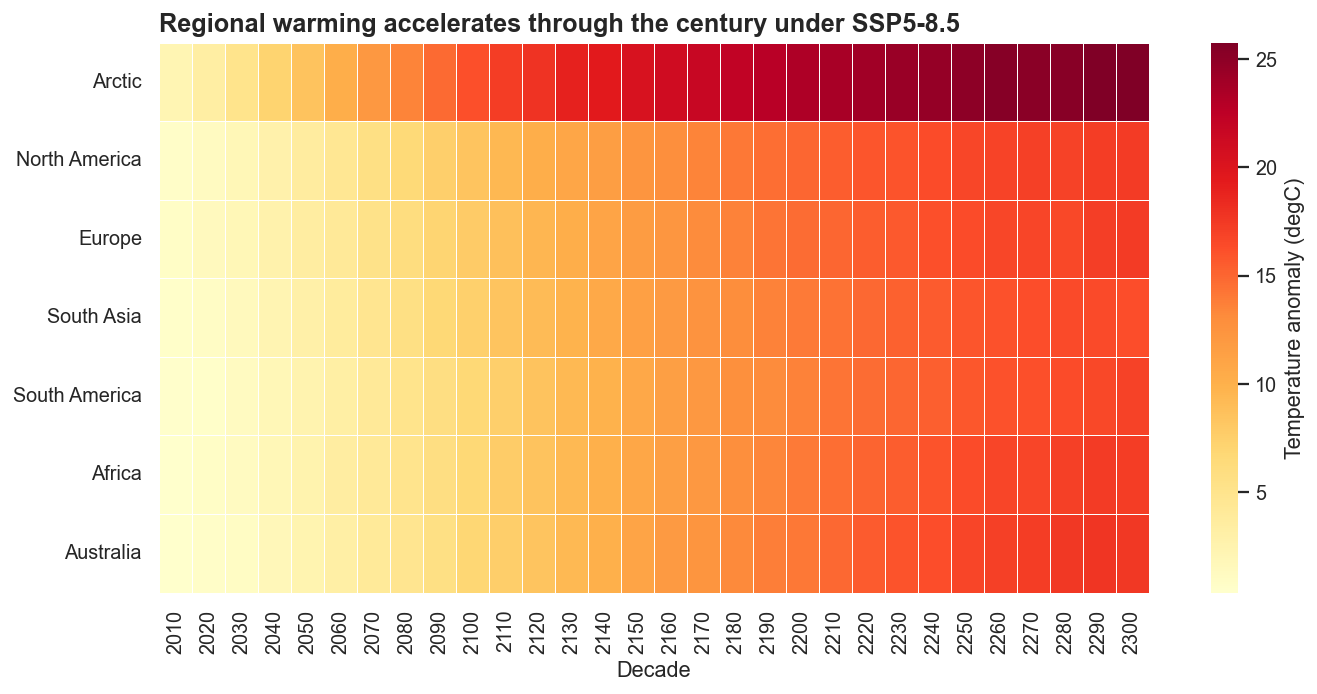

In [28]:
heat_df = timeseries[
    (timeseries["variable"] == "tas")
    & (timeseries["scenario"] == "ssp585")
    & (timeseries["region"] != "Global")
].copy()
heat_df["decade"] = (heat_df["year"] // 10) * 10
heat_pivot = heat_df.pivot_table(index="region", columns="decade", values="anomaly", aggfunc="mean")
heat_pivot = heat_pivot.loc[bar_df["region"]]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(
    heat_pivot,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Temperature anomaly (degC)"},
    ax=ax,
)
ax.set_title("Regional warming accelerates through the century under SSP5-8.5", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("")
savefig("06_regional_temperature_heatmap.png")
plt.show()

## Data Exports Summary

### CSVs for D3 charts
- `data/processed/cmip6_anomaly_timeseries.csv` — Yearly anomalies (2015–2100) for every scenario × variable × region
- `data/processed/cmip6_region_summary.csv` — Mid-century and late-century mean anomalies summarised per region

### TopoJSON for map context
- `data/processed/world-110m.json` — World countries basemap (110m resolution)

### Gridded JSON arrays for D3 geo maps
- `data/processed/grids/{scenario}_{variable}_latecentury.json` — Late-century mean anomaly as `[{lat, lon, value}, ...]`
- One file for each combination of 4 SSP scenarios × 2 climate variables

### Next Steps

These exports feed directly into the interactive website. The D3 front-end will:
- Load CSVs for line charts, bar charts, scatter plots, and heatmaps
- Load TopoJSON for the world map background
- Load gridded JSON for pixel-level geographic anomaly maps
- Use Scrollama to drive scroll-triggered transitions between visualization states